In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [2]:
fund_master = pd.read_csv("../data/processed/fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history.csv")
aum = pd.read_csv("../data/processed/aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/category_inflows.csv")
folio = pd.read_csv("../data/processed/industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance.csv")
transactions = pd.read_csv("../data/processed/investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="Market Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

fig.write_image("../charts/nav_trend.png")

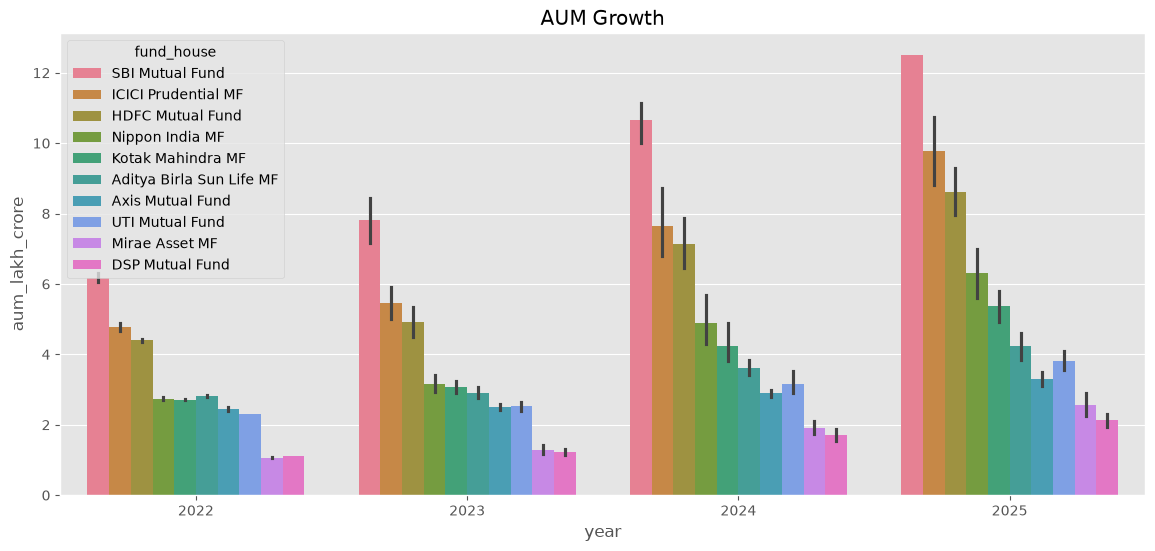

In [4]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth")

plt.savefig("../charts/aum_growth.png")

plt.show()

In [5]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr"
)

fig.show()

fig.write_image("../charts/sip_trend.png")

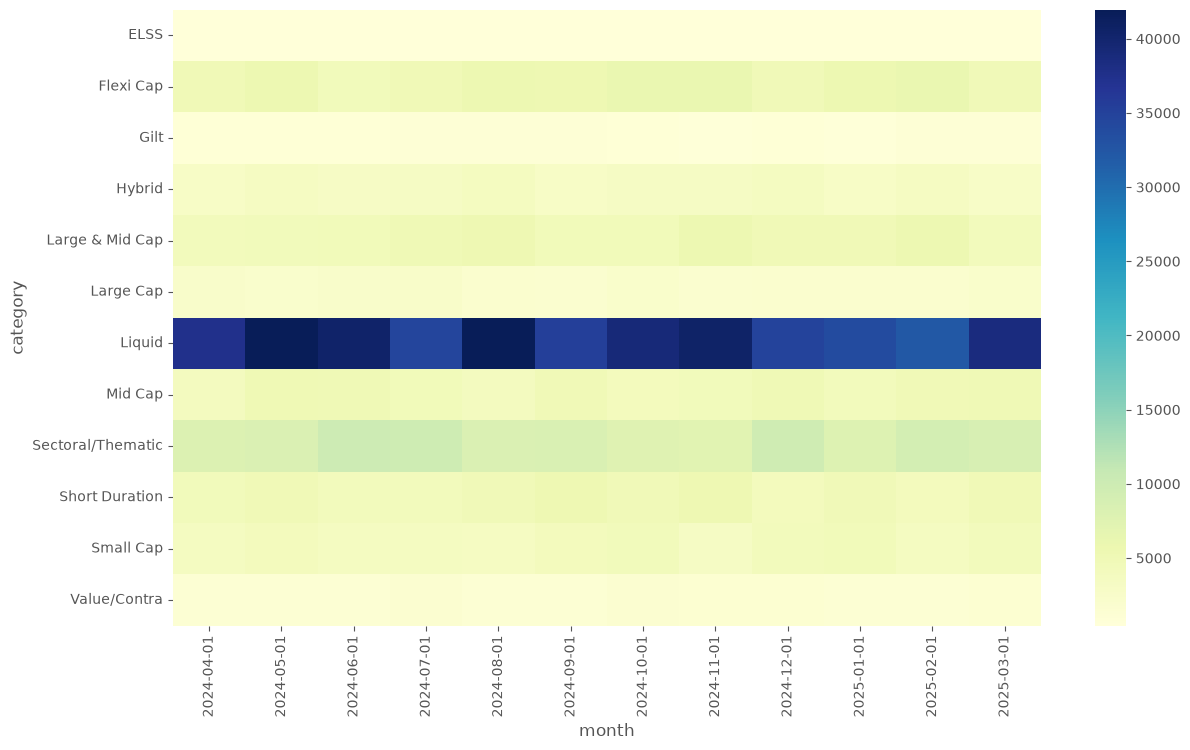

In [6]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.savefig("../charts/category_heatmap.png")

plt.show()

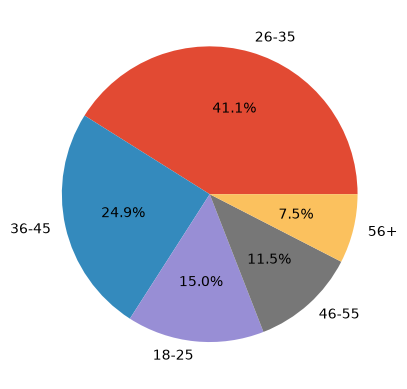

In [7]:
transactions.age_group.value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.savefig("../charts/demographics_pie.png")

plt.show()

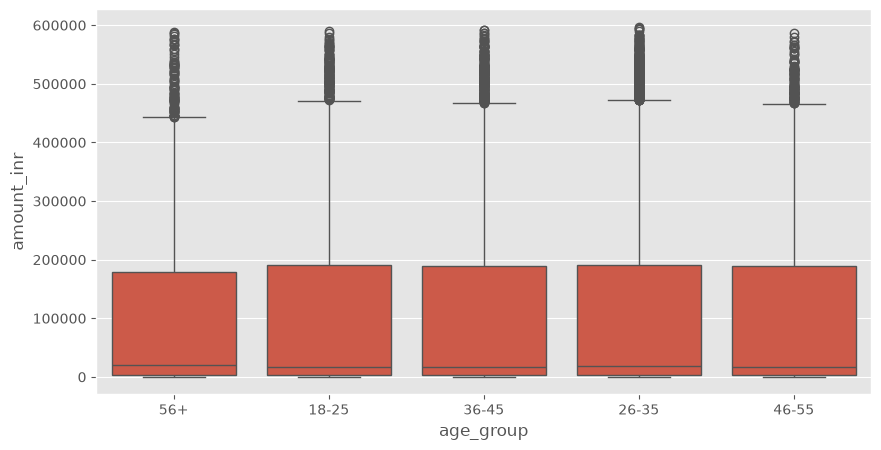

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.savefig("../charts/age_boxplot.png")

plt.show()

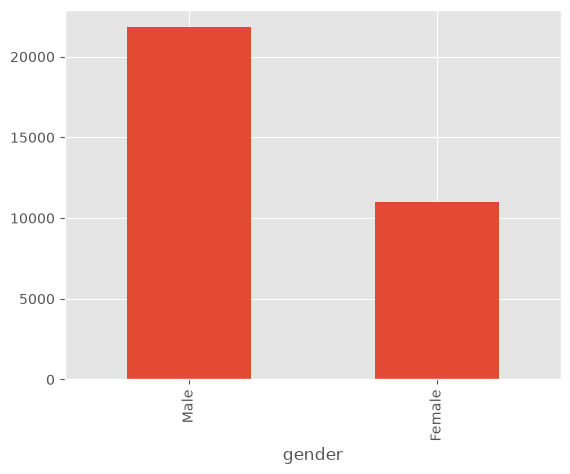

In [9]:
transactions.gender.value_counts().plot.bar()

plt.savefig("../charts/gender_split.png")

plt.show()

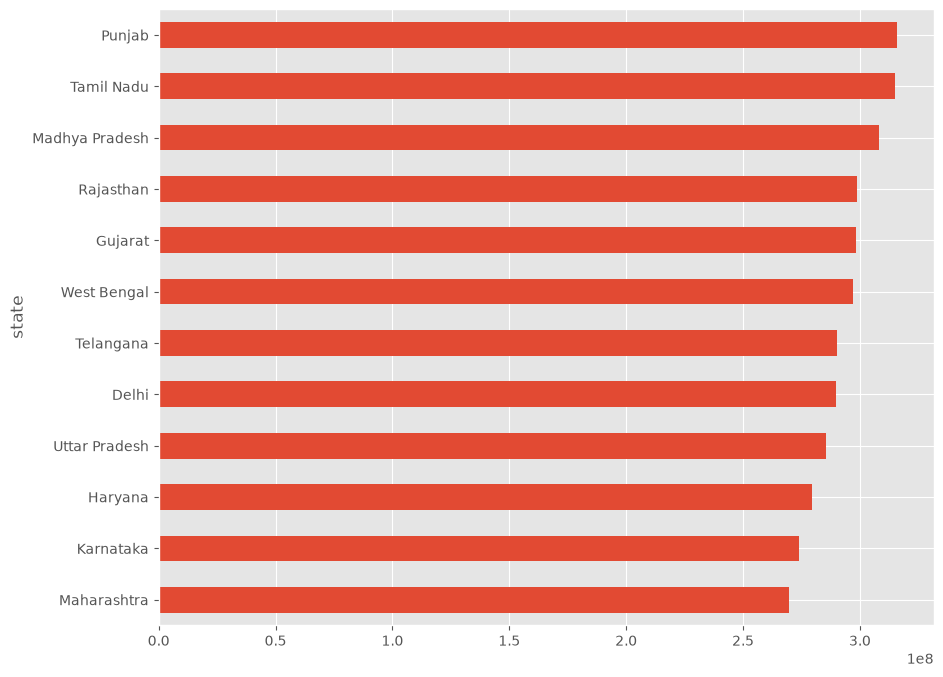

In [10]:
state = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state.plot.barh(figsize=(10,8))

plt.savefig("../charts/state_bar.png")

plt.show()

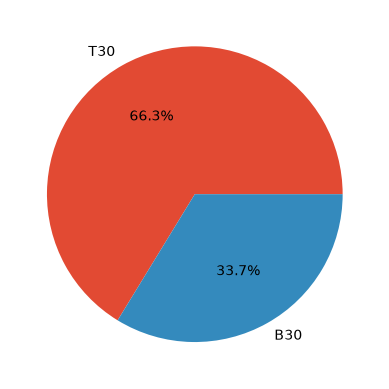

In [11]:
transactions.city_tier.value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.savefig("../charts/city_tier.png")

plt.show()

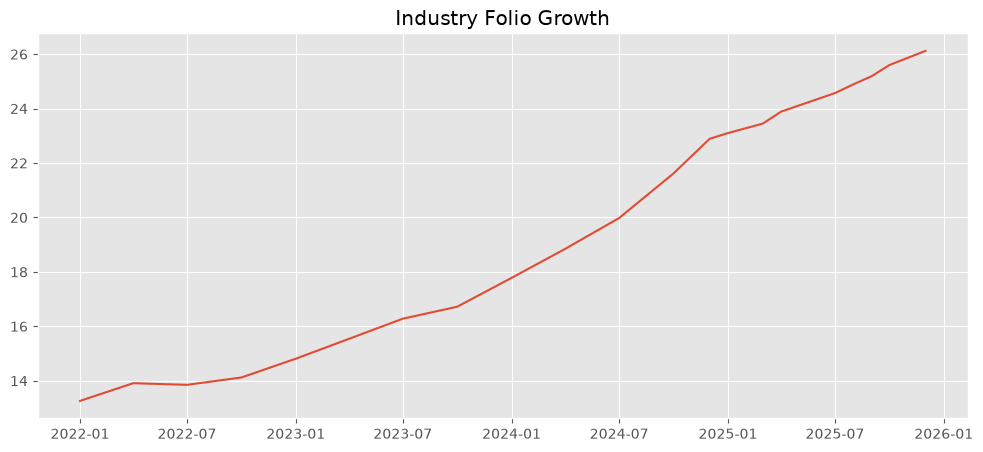

In [12]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig("../charts/folio_growth.png")

plt.show()

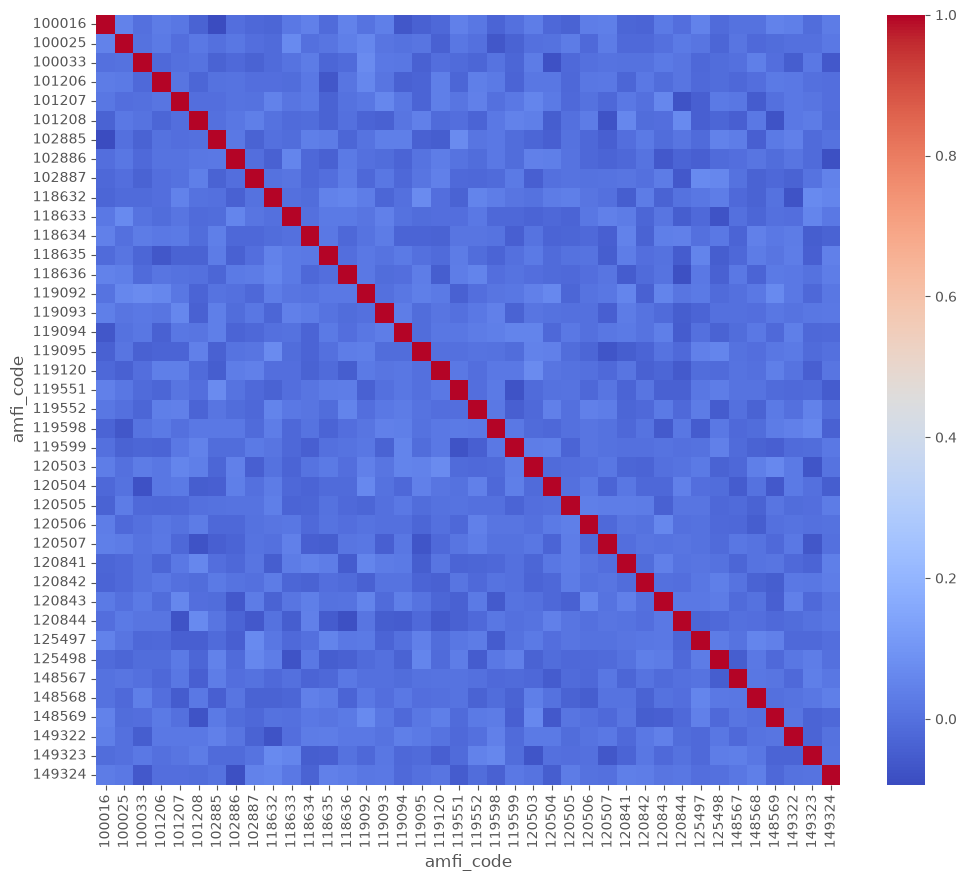

In [13]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.savefig("../charts/correlation_heatmap.png")

plt.show()

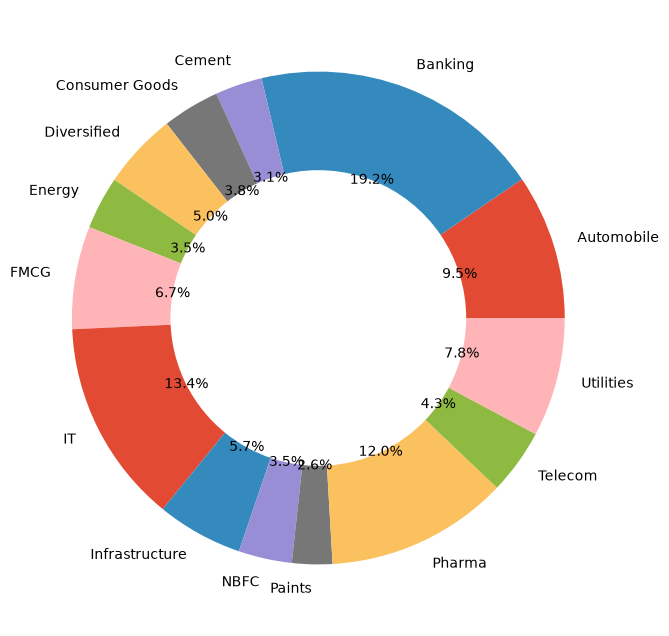

In [14]:
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.4),
    autopct="%1.1f%%"
)

plt.savefig("../charts/sector_donut.png")

plt.show()